In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
file_path = '/kaggle/input/datasets/camnugent/sandp500/all_stocks_5yr.csv'
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/camnugent/sandp500/merge.sh
/kaggle/input/datasets/camnugent/sandp500/getSandP.py
/kaggle/input/datasets/camnugent/sandp500/all_stocks_5yr.csv
/kaggle/input/datasets/camnugent/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._.DS_Store
/kaggle/input/datasets/camnugent/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._ABC_data.csv
/kaggle/input/datasets/camnugent/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._AAPL_data.csv
/kaggle/input/datasets/camnugent/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._A_data.csv
/kaggle/input/datasets/camnugent/sandp500/individual_stocks_5yr/__MACOSX/individual_stocks_5yr/._MAS_data.csv
/kaggle/input/datasets/camnugent/sandp500/individual_stocks_5yr/individual_stocks_5yr/CL_data.csv
/kaggle/input/datasets/camnugent/sandp500/individual_stocks_5yr/individual_stocks_5yr/FDX_data.csv
/kaggle/input/datasets/camnugent/sandp500/individual_stocks_5yr/individual_stocks_5yr/AMAT_

In [2]:
df = pd.read_csv(file_path)

prices = df.pivot(index='date' ,columns='Name',values='close')

prices.index = pd.to_datetime(prices.index)

print(prices.index)

DatetimeIndex(['2013-02-08', '2013-02-11', '2013-02-12', '2013-02-13',
               '2013-02-14', '2013-02-15', '2013-02-19', '2013-02-20',
               '2013-02-21', '2013-02-22',
               ...
               '2018-01-25', '2018-01-26', '2018-01-29', '2018-01-30',
               '2018-01-31', '2018-02-01', '2018-02-02', '2018-02-05',
               '2018-02-06', '2018-02-07'],
              dtype='datetime64[ns]', name='date', length=1259, freq=None)


Now we have to normalize every datapoint as the changes in them along a period of time would have different scales. For example, a $5 drop from $500 is nothing compared to $5 from $20.

To solve that issue, we use PERCENTAGE.

In [3]:
returns = prices.ffill().pct_change().dropna()

In [4]:
market_return = returns.median(axis=1)

test_stock = 'AAPL'
covariance = returns[test_stock].cov(market_return)
market_variance = market_return.var()

beta = covariance / market_variance
print(f"The manual beta for {test_stock} is: {beta:.2f}")
print(f"The median of all the stocks by {test_stock} in 2013-2018 is {market_return}.")

The manual beta for AAPL is: 1.13
The median of all the stocks by AAPL in 2013-2018 is date
2017-12-06   -0.000685
2017-12-07    0.003986
2017-12-08    0.005607
2017-12-11    0.000301
2017-12-12    0.000085
2017-12-13   -0.000815
2017-12-14   -0.005979
2017-12-15    0.009573
2017-12-18    0.006129
2017-12-19   -0.002590
2017-12-20   -0.001089
2017-12-21    0.001081
2017-12-22    0.000260
2017-12-26    0.000526
2017-12-27    0.001068
2017-12-28    0.002469
2017-12-29   -0.004979
2018-01-02    0.006391
2018-01-03    0.005101
2018-01-04    0.004571
2018-01-05    0.004886
2018-01-08    0.003325
2018-01-09   -0.000438
2018-01-10   -0.003309
2018-01-11    0.008135
2018-01-12    0.005653
2018-01-16   -0.005813
2018-01-17    0.008390
2018-01-18   -0.003143
2018-01-19    0.005886
2018-01-22    0.005262
2018-01-23    0.001385
2018-01-24    0.000275
2018-01-25    0.000000
2018-01-26    0.008676
2018-01-29   -0.007556
2018-01-30   -0.009968
2018-01-31    0.000755
2018-02-01   -0.003324
2018-02-02 

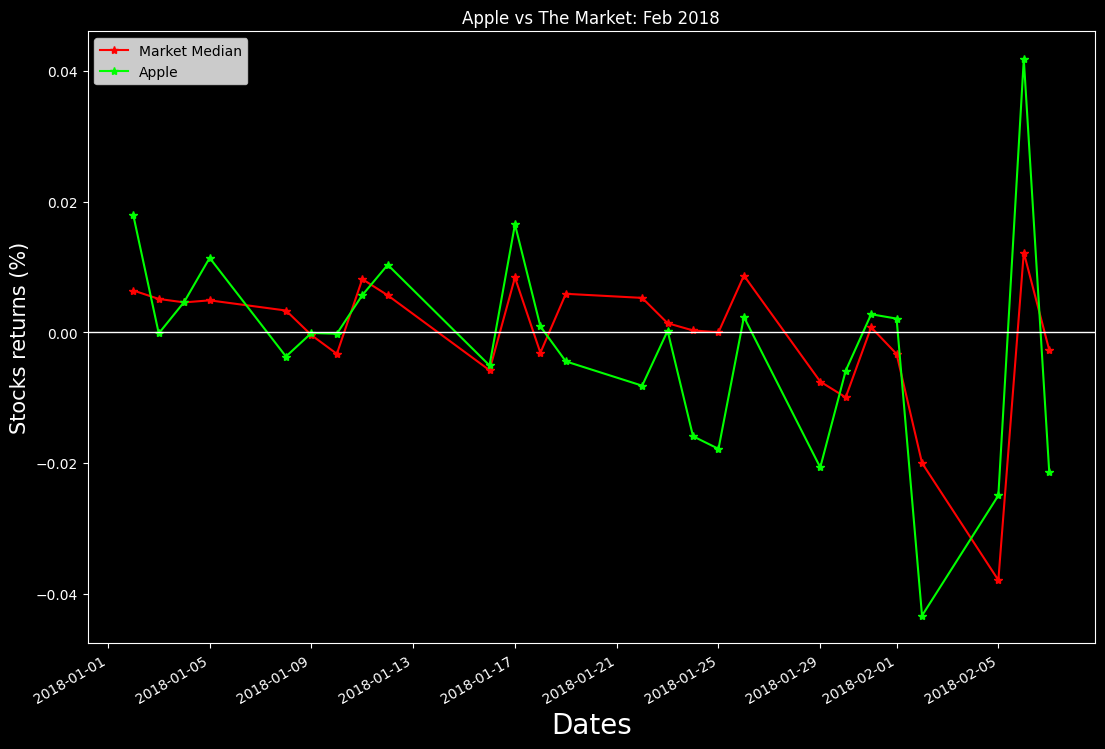

In [5]:
import matplotlib.pyplot as plt

crash_check = pd.DataFrame({
    'Market Median': returns.median(axis=1),
    'Apple': returns['AAPL']
}
)

#Filter
early_2018 = crash_check.loc['2018-01-01':'2018-02-07']

#Graph plotting
fig = plt.figure(figsize=(13, 9), facecolor='black')
ax = early_2018.plot(ax=plt.gca(),marker = '*', ls = '-', color=['#FF0000','#00FF00'])
ax.set_facecolor('black')
for spine in ax.spines.values():
    spine.set_edgecolor('white')
plt.title("Apple vs The Market: Feb 2018", color = 'white')
plt.ylabel("Stocks returns (%)", color = 'white', fontsize = '15')
plt.xlabel("Dates", color = 'white',fontsize = '20')
ax.tick_params(axis='x',colors='white')
ax.tick_params(axis='y',colors='white')
plt.axhline(0, color='white', lw = 1)
plt.grid(False)
plt.show()
